In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from Pipeline.Algorithm.ArtificialBeeColonyElm import ArtificialBeeColonyElm
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Methodology.EvaluationMatrix import EvaluationMatrix

In [4]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_0()
gallstone_dataset.normal_data_split()

In [ ]:
x_tr, x_val, y_tr, y_val = train_test_split(gallstone_dataset.x_train,
                                            gallstone_dataset.y_train,
                                            test_size=GlobalSetting.test_set_size,
                                            random_state=GlobalSetting.data_split_seed,
                                            stratify=gallstone_dataset.y_train)
scaler = MinMaxScaler()
x_tr_scaled = pd.DataFrame(scaler.fit_transform(x_tr), columns=x_tr.columns)
x_val_scaled = pd.DataFrame(scaler.transform(x_val), columns=x_tr.columns)

In [ ]:
abc_model = ArtificialBeeColonyElm(
    feature_size=x_tr.shape[1],
    hidden_size=30,
    activation_function=GlobalSetting.sigmoid,
    regularization_lambda=2 ** -8,
    fitness_function=GlobalSetting.evaluation_function,
    solution_size=50,
    trial_limit=40,
    max_iteration=100
)
abc_model.init_random_state(42)
abc_model.employed_bee_apply_algo3()
abc_model.onlooker_bee_apply_algo2()
abc_model.apply_validation_dataset(x_val_scaled, y_val)
abc_model.fit(x_tr_scaled, y_tr)
val_fitness_curve = abc_model.val_fitness_curve
val_fitness_curve

In [ ]:
best_fitness_curve = abc_model.convergence_curve
best_fitness_curve

In [6]:
y_pred = abc_model.predict(x_test=gallstone_dataset.x_test_scaled)
evaluation_result = EvaluationMatrix(y_true=gallstone_dataset.y_test, y_pred=y_pred)
evaluation_result.get_all_metrics()

{'Accuracy': np.float64(0.78125),
 'Precision': 0.9090909090909091,
 'Recall': 0.625,
 'NPV': 0.7142857142857143,
 'Specificity': 0.9375,
 'F1-Score': 0.7407407407407407,
 'F2-Score': 0.6666666666666666,
 'Bal Accuracy': 0.78125,
 'MCC': 0.592156525463792}

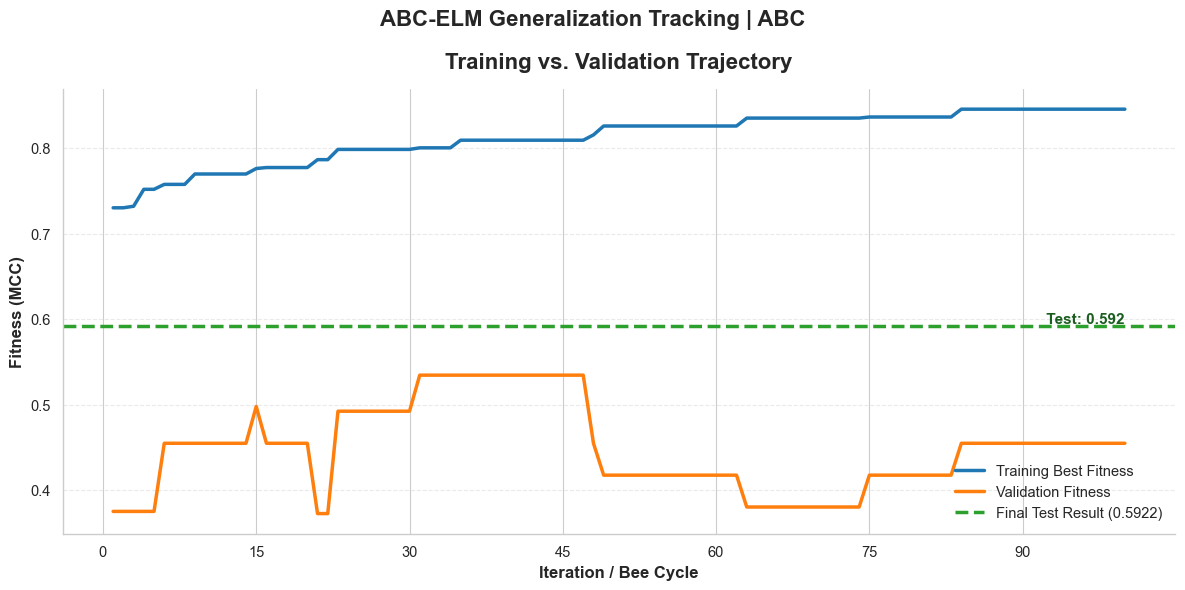

In [10]:
from Pipeline.Global.Plotting import Plotting

metric_to_track = GlobalSetting.evaluation_function
final_test_score = evaluation_result.get_all_metrics()[metric_to_track]

# 2. Call the new plotting method
Plotting.plot_train_val_curve(
    convergence_curve=abc_model.convergence_curve,
    val_fitness_curve=abc_model.val_fitness_curve,
    experiment_name="ABC",
    final_test_result=final_test_score,
    fitness_metric=metric_to_track,
    is_final_record=False  # Set to True to save the PNG
)